**Model Training**

**Import Data and Required Packages**

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [22]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [23]:
heart_df_from_csv = pd.read_csv('data/preprocessed.csv')

In [24]:
print("DataFrame loaded from 'preprocessed.csv':")
display(heart_df_from_csv.head())

DataFrame loaded from 'preprocessed.csv':


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


**Handling Class Imbalance with SMOTE**

As identified, the target variable num exhibits significant class imbalance. To mitigate the potential bias this can introduce in machine learning models, we will use SMOTE (Synthetic Minority Over-sampling Technique).

SMOTE works by creating synthetic samples for the minority classes. It does not simply duplicate existing minority class samples, but rather generates new samples along the line segments joining existing minority class samples and their nearest neighbors. This helps to increase the number of instances in the minority classes, thereby balancing the dataset and potentially improving model performance, especially in terms of recall and precision for these under-represented classes.

In [25]:
# First, separate features (X) and target (y)
X = heart_df_from_csv.drop('num', axis=1)
y = heart_df_from_csv['num']

# Display the original class distribution for comparison
print("Original class distribution:\n", y.value_counts())

Original class distribution:
 num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [26]:
# Install imbalanced-learn if not already installed
!pip install imbalanced-learn

In [27]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display the new class distribution after SMOTE
print("\nClass distribution after SMOTE:\n", y_resampled.value_counts())



Class distribution after SMOTE:
 num
0    164
2    164
1    164
3    164
4    164
Name: count, dtype: int64


As you can see, after applying SMOTE, the number of instances for each class in num is now equalized. This balanced dataset can now be used for training machine learning models without the inherent bias towards the majority class that existed previously.

**Splitting the Data into Training and Testing Sets**

After handling the class imbalance with SMOTE, it's essential to split our dataset into training and testing sets. This step is fundamental in machine learning for the following reasons:

**Model Evaluation:** The training set is used to train the machine learning model, allowing it to learn patterns and relationships within the data. The testing set, which the model has not seen during training, is then used to evaluate its performance and generalization ability. This helps in assessing how well the model is likely to perform on new, real-world data.

**Preventing Overfitting:** Splitting the data helps prevent overfitting, a common problem where a model learns the training data too well, including its noise and outliers, and consequently performs poorly on unseen data. By evaluating on a separate test set, we can identify if the model is overfitting.

**Unbiased Performance Estimate:** A distinct test set provides an unbiased estimate of the model's performance. If we were to evaluate the model on the same data it was trained on, the performance metrics would be overly optimistic.

In [28]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
# test_size=0.20 means 20% of the data will be used for testing, and 80% for training.
# random_state=42 ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.20, random_state=42, stratify=y_resampled)

# Display the shapes of the resulting datasets to verify the split
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Also, check the class distribution in the training and test sets to ensure stratification worked
print("\nClass distribution in y_train:\n", y_train.value_counts())
print("\nClass distribution in y_test:\n", y_test.value_counts())


Shape of X_train: (656, 13)
Shape of X_test: (164, 13)
Shape of y_train: (656,)
Shape of y_test: (164,)

Class distribution in y_train:
 num
1    132
3    131
2    131
4    131
0    131
Name: count, dtype: int64

Class distribution in y_test:
 num
2    33
4    33
0    33
3    33
1    32
Name: count, dtype: int64


**Applying StandardScaler for Feature Scaling**

Feature scaling is a crucial preprocessing step, especially for algorithms that are sensitive to the magnitude of feature values (e.g., K-Nearest Neighbors, Support Vector Machines, neural networks). StandardScaler standardizes features by removing the mean and scaling to unit variance. The formula for standardization is:

z=(x−u)/s 

where  u  is the mean of the training samples, and  s  is the standard deviation of the training samples.

It's critical to fit the StandardScaler ONLY on the training data (X_train) to learn the mean and standard deviation. Then, these learned parameters are used to transform both X_train and X_test. This practice prevents data leakage from the test set into the training process, ensuring that the model's performance evaluation on the test set is unbiased and reflective of its generalization ability to unseen data.

In [29]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the *same* fitted scaler
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames, preserving column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Display the shapes of the scaled datasets and a sample of X_train_scaled
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

print("\nFirst 5 rows of X_train_scaled:")
display(X_train_scaled.head())

print("\nDescriptive statistics of X_train_scaled (should have mean close to 0 and std close to 1):")
display(X_train_scaled.describe())


Shape of X_train_scaled: (656, 13)
Shape of X_test_scaled: (164, 13)

First 5 rows of X_train_scaled:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
570,-2.018350,-1.422337,0.705925,-1.488104,-1.616230,-0.271385,0.026993,-1.356557,1.48324,0.135855,0.640955,-1.116775,0.847311
435,-1.254262,-1.422337,0.705925,-1.047582,0.881152,-0.271385,0.026993,0.332976,-0.67420,-0.459420,-1.253038,-0.437559,-0.765839
697,-2.273046,-1.422337,-2.625636,-0.858787,-0.377371,-0.271385,-1.079702,1.829420,-0.67420,1.975251,0.640955,-1.073291,0.847311
29,-2.018350,0.703068,0.705925,-1.488104,-1.616230,-0.271385,1.133687,-1.356557,1.48324,0.135855,0.640955,-1.123836,0.847311
55,-0.235477,0.703068,0.705925,-0.607061,0.330548,-0.271385,1.133687,-1.597919,1.48324,0.345646,0.640955,-0.108115,0.847311



Descriptive statistics of X_train_scaled (should have mean close to 0 and std close to 1):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02,6.560000e+02
mean,-2.924490e-16,7.311225e-17,4.197185e-17,-5.659430e-16,5.415722e-17,-1.353931e-17,9.748300e-17,3.574377e-16,5.686508e-17,1.787188e-16,-8.665155e-17,1.678874e-16,1.083144e-17
std,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00,1.000763e+00
min,-2.782439e+00,-1.422337e+00,-2.625636e+00,-2.495011e+00,-2.422471e+00,-2.713849e-01,-1.079702e+00,-3.239180e+00,-6.741999e-01,-1.857155e+00,-1.253038e+00,-1.123836e+00,-1.540224e+00
25%,-6.175216e-01,-1.422337e+00,-4.045951e-01,-7.958556e-01,-7.509952e-01,-2.713849e-01,-1.079702e+00,-7.290160e-01,-6.741999e-01,-6.134899e-01,-1.253038e+00,-1.123836e+00,-1.217858e+00
50%,1.465667e-01,7.030684e-01,7.059254e-01,-1.036070e-01,-8.240473e-02,-2.713849e-01,2.699254e-02,4.334212e-02,-6.741999e-01,-3.377243e-01,6.409549e-01,-1.081148e-01,5.714804e-01
75%,6.559590e-01,7.030684e-01,7.059254e-01,5.886415e-01,6.845078e-01,-2.713849e-01,1.133687e+00,7.794959e-01,1.483240e+00,5.471948e-01,6.409549e-01,9.076068e-01,8.473107e-01
max,2.693528e+00,7.030684e-01,7.059254e-01,4.175748e+00,6.190547e+00,3.684804e+00,1.133687e+00,2.553506e+00,1.483240e+00,4.541458e+00,2.534948e+00,1.923328e+00,8.473107e-01


**Logistic Regression** is a statistical model that in its basic form uses a logistic function to model a binary dependent variable, although it can be extended to handle multi-class classification problems, as is the case here with num.

Despite its name, Logistic Regression is a classification algorithm rather than a regression algorithm. It works by estimating the probability that a given instance belongs to a particular class. If the estimated probability is greater than a certain threshold (commonly 0.5), the model predicts the positive class; otherwise, it predicts the negative class.

Key concepts of Logistic Regression:

**Sigmoid Function:** The core of logistic regression is the sigmoid (or logistic) function, which maps any real-valued number into a value between 0 and 1, suitable for interpreting as a probability.

**Decision Boundary:** The model learns a decision boundary that separates the classes.

**Multi-class Classification:** For multi-class problems, Logistic Regression typically uses a 'one-vs-rest' (OvR) or 'multinomial' (MvM) approach. Scikit-learn's LogisticRegression uses OvR by default when solver is 'liblinear' or 'saga', and 'multinomial' if multi_class='multinomial' and solver supports it (like 'lbfgs', 'saga', 'newton-cg').

**Solvers for Logistic Regression:** Scikit-learn's LogisticRegression offers several solvers, each with its strengths:

**'liblinear':** Good for small datasets, supports L1 and L2 regularization, and is efficient for binary classification. It also handles multi-class via OvR.

'**lbfgs':** Default, works well for small to medium-sized datasets, supports L2 regularization.

'**newton-cg**', 'sag', 'saga': Suitable for large datasets. 'saga' is a more flexible and robust version of 'sag' and supports L1 regularization.

For this problem, given it's a multi-class classification and liblinear is generally robust for various dataset sizes and supports OvR, we will use it.

### Logistic Regression Model Evaluation for Different Solvers ###

Training with Solver: liblinear...
Training with Solver: lbfgs...
Training with Solver: newton-cg...
Training with Solver: sag...
Training with Solver: saga...

### Summary of All Solver Performances ###
Solver: liblinear, Accuracy: 0.5793, Macro Avg F1-score: 0.5640
Solver: lbfgs, Accuracy: 0.5732, Macro Avg F1-score: 0.5664
Solver: newton-cg, Accuracy: 0.5732, Macro Avg F1-score: 0.5664
Solver: sag, Accuracy: 0.5732, Macro Avg F1-score: 0.5664
Solver: saga, Accuracy: 0.5732, Macro Avg F1-score: 0.5664

Based on a combined consideration of accuracy and macro average F1-score, the best performing solver is: liblinear

--- Detailed Evaluation for Best Solver: liblinear ---
Accuracy: 0.5793
Macro Avg F1-score: 0.5640
Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.79      0.72        33
           1       0.35      0.25      0.29        32
           2       0

,0,1,2,3,4
0,26,4,1,1,1
1,12,8,5,1,6
2,1,3,17,3,9
3,0,6,4,18,5
4,0,2,0,5,26


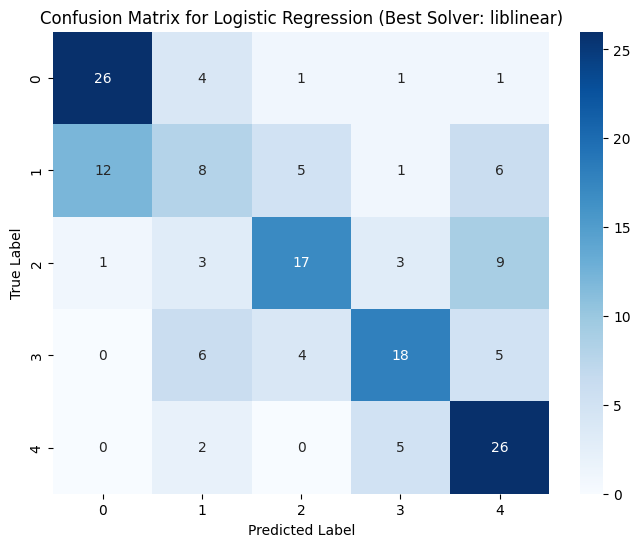

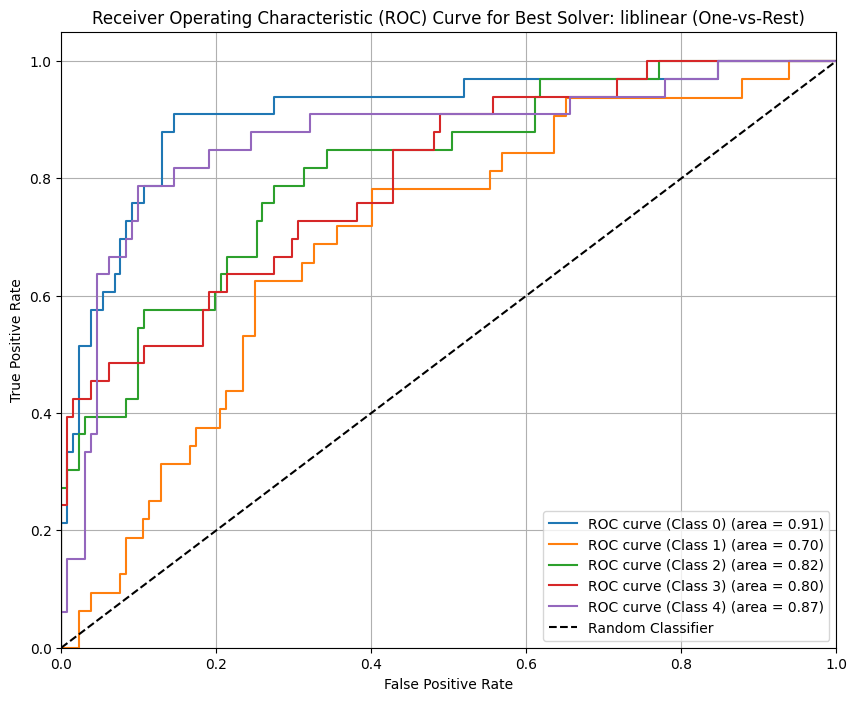

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the solvers to test
solvers = ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']

# Dictionary to store results
results = {}

print("### Logistic Regression Model Evaluation for Different Solvers ###\n")

# Loop through each solver to train and evaluate, but don't print all details yet
for solver_name in solvers:
    print(f"Training with Solver: {solver_name}...")
    log_reg_model = LogisticRegression(solver=solver_name, random_state=42, multi_class='auto', max_iter=1000)
    log_reg_model.fit(X_train_scaled, y_train)
    y_pred = log_reg_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results[solver_name] = {'accuracy': accuracy, 'f1_macro': f1_macro, 'model': log_reg_model}

# Identify the best solver based on accuracy and F1-score
best_solver_name = max(results, key=lambda solver: results[solver]['accuracy'] + results[solver]['f1_macro'])
best_solver_metrics = results[best_solver_name]
best_log_reg_model = best_solver_metrics['model']

print("\n### Summary of All Solver Performances ###")
for solver_name, metrics in results.items():
    print(f"Solver: {solver_name}, Accuracy: {metrics['accuracy']:.4f}, Macro Avg F1-score: {metrics['f1_macro']:.4f}")

print(f"\nBased on a combined consideration of accuracy and macro average F1-score, the best performing solver is: {best_solver_name}")

# Now, evaluate and visualize only for the best solver
print(f"\n--- Detailed Evaluation for Best Solver: {best_solver_name} ---")

y_pred_best = best_log_reg_model.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
f1_macro_best = f1_score(y_test, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Macro Avg F1-score: {f1_macro_best:.4f}")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix for the best solver
print("Confusion Matrix:\n")
cm_best = confusion_matrix(y_test, y_pred_best)
display(pd.DataFrame(cm_best, index=best_log_reg_model.classes_, columns=best_log_reg_model.classes_))

# Visualize the Confusion Matrix for the best solver
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_log_reg_model.classes_,
            yticklabels=best_log_reg_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Logistic Regression (Best Solver: {best_solver_name})')
plt.show()

# ROC Curve and AUC for the best solver (multi-class One-vs-Rest)
y_prob_best = best_log_reg_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))
for i in range(len(best_log_reg_model.classes_)):
    fpr, tpr, _ = roc_curve(y_test, y_prob_best[:, i], pos_label=best_log_reg_model.classes_[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (Class {best_log_reg_model.classes_[i]}) (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Best Solver: {best_solver_name} (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Random Forest Classifier with Grid Search for Hyperparameter Tuning**

Now, let's apply a Random Forest Classifier to our dataset. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It is known for its robustness against overfitting and its ability to handle non-linear relationships.

To optimize its performance, we will perform hyperparameter tuning using Grid Search. Grid Search exhaustively searches through a specified subset of hyperparameters, evaluating every combination to find the set that yields the best performance. This ensures we find the most effective configuration for our Random Forest model on this dataset.

### Random Forest Classifier with Grid Search ###

Performing Grid Search... This may take some time.

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Grid Search completed.

Best parameters found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best macro average F1-score from Grid Search (cross-validation): 0.8510

--- Detailed Evaluation for Best Random Forest Model ---
Accuracy on Test Set: 0.8598
Macro Avg F1-score on Test Set: 0.8581

Classification Report on Test Set:

              precision    recall  f1-score   support

           0       0.77      0.82      0.79        33
           1       0.77      0.72      0.74        32
           2       0.94      0.91      0.92        33
           3       0.90      0.85      0.88        33
           4       0.92      1.00      0.96        33

    accuracy                           0.86       164
   macro avg       0.86      0.86      0.86       164
weighte

,0,1,2,3,4
0,27,5,1,0,0
1,6,23,1,2,0
2,1,0,30,1,1
3,1,2,0,28,2
4,0,0,0,0,33


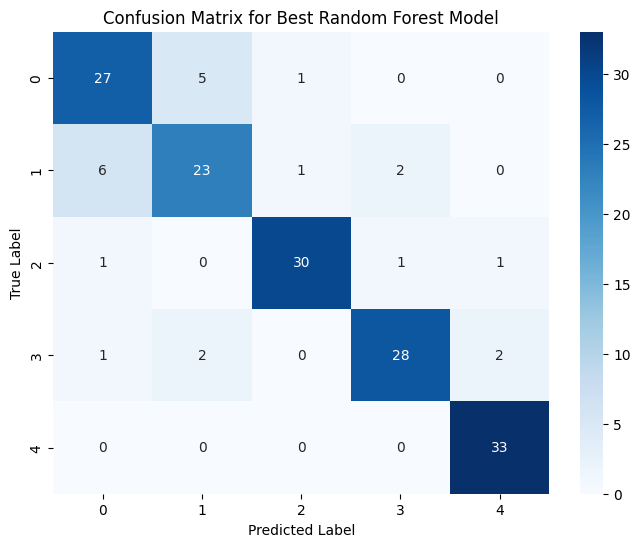

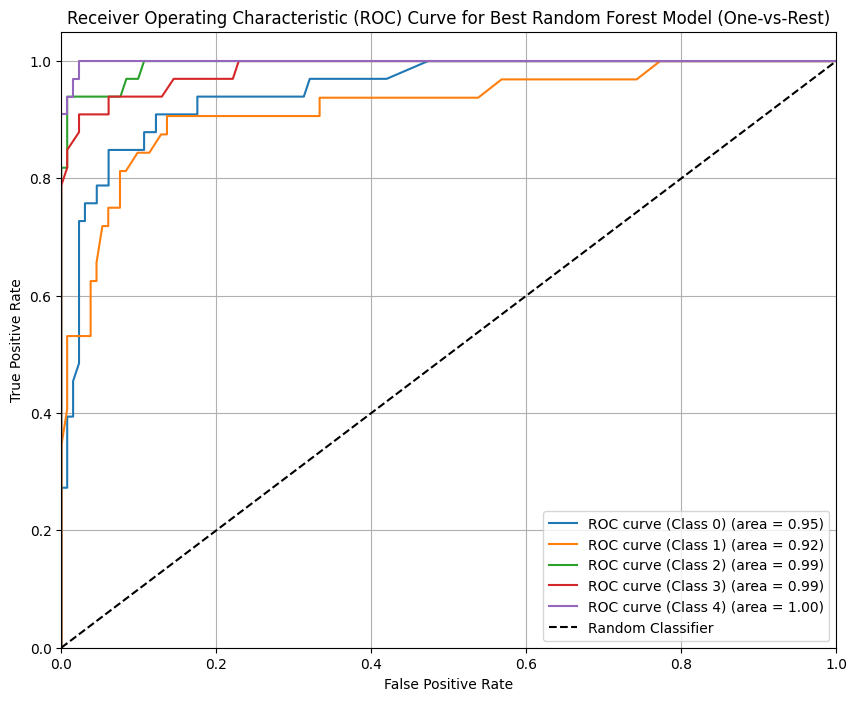

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Random Forest Classifier with Grid Search ###\n")

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define the parameter grid for Grid Search
# These parameters are chosen to explore a reasonable range of values
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='f1_macro' because we have a multi-class imbalanced dataset (even after SMOTE, we want to ensure good performance across all classes)
# n_jobs=-1 uses all available processors
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid,
                           cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

# Fit Grid Search to the scaled training data
print("Performing Grid Search... This may take some time.\n")
grid_search.fit(X_train_scaled, y_train)

print("Grid Search completed.\n")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_rf_model = grid_search.best_estimator_

print(f"Best parameters found: {best_params}")
print(f"Best macro average F1-score from Grid Search (cross-validation): {best_score:.4f}\n")

# Evaluate the best Random Forest model on the test set
y_pred_rf = best_rf_model.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')

print("--- Detailed Evaluation for Best Random Forest Model ---")
print(f"Accuracy on Test Set: {accuracy_rf:.4f}")
print(f"Macro Avg F1-score on Test Set: {f1_macro_rf:.4f}")

print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix for the best Random Forest model
print("\nConfusion Matrix on Test Set:\n")
cm_rf = confusion_matrix(y_test, y_pred_rf)
display(pd.DataFrame(cm_rf, index=best_rf_model.classes_, columns=best_rf_model.classes_))

# Visualize the Confusion Matrix for the best Random Forest model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_rf_model.classes_,
            yticklabels=best_rf_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Random Forest Model')
plt.show()

# ROC Curve and AUC for the best Random Forest model (multi-class One-vs-Rest)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))
for i in range(len(best_rf_model.classes_)):
    fpr, tpr, _ = roc_curve(y_test, y_prob_rf[:, i], pos_label=best_rf_model.classes_[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (Class {best_rf_model.classes_[i]}) (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Best Random Forest Model (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Support Vector Machine (SVM) with Randomized Search for Hyperparameter Tuning**

Support Vector Machines (SVMs) are powerful supervised learning models used for classification and regression tasks. They work by finding the optimal hyperplane that best separates data points of different classes in a high-dimensional space. SVMs are particularly effective in high-dimensional spaces and when the number of dimensions is greater than the number of samples.

For hyperparameter tuning, instead of exhaustive Grid Search, we will use Randomized Search. Randomized Search is a good alternative when the search space for hyperparameters is large, as it samples a fixed number of parameter settings from specified distributions. This can be more computationally efficient than Grid Search while often yielding comparable or even better results by exploring more diverse parameter combinations.

### Support Vector Machine (SVM) with Randomized Search ###

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Performing Randomized Search... This may take some time.

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Randomized Search completed.

Best parameters found: {'C': 9.444574254983555, 'gamma': 0.4108318894699928, 'kernel': 'rbf'}
Best macro average F1-score from Randomized Search (cross-validation): 0.8278

--- Detailed Evaluation for Best SVM Model ---
Accuracy on Test Set: 0.8720
Macro Avg F1-score on Test Set: 0.8728

Classification Report on Test Set:

              precision    recall  f1-score   support

           0       0.77      0.82      0.79        33
           1       0.79      0.81      0.80        32
           2       0.91      0.88      0.89        33
           3       1.00      0.91      0.95        33
           4       0.91      0.94      0.93        

,0,1,2,3,4
0,27,5,1,0,0
1,4,26,1,0,1
2,2,1,29,0,1
3,2,0,0,30,1
4,0,1,1,0,31


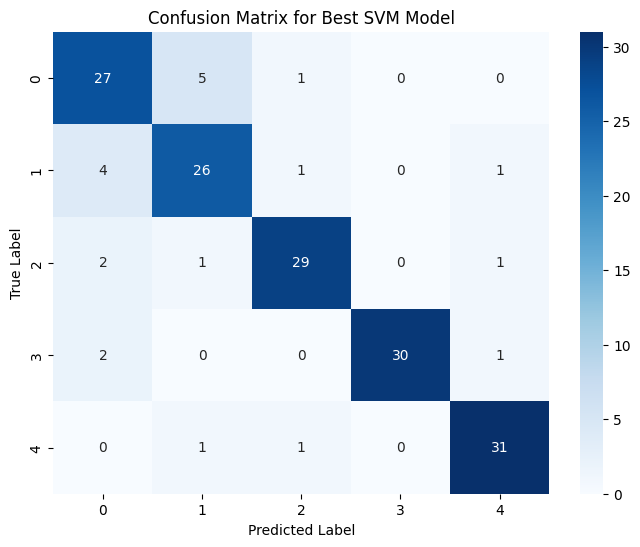

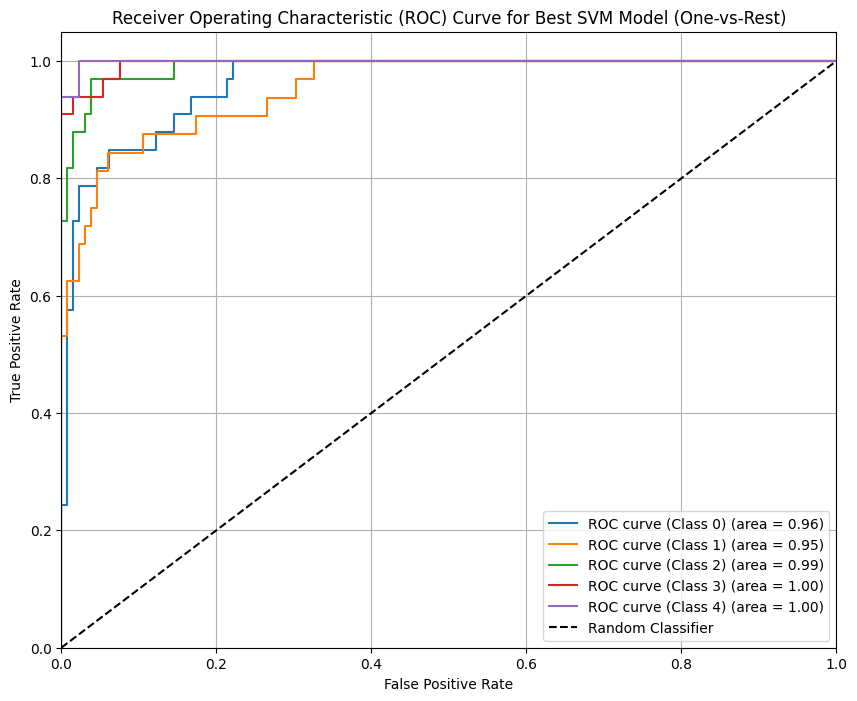

In [33]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import reciprocal, uniform

print("### Support Vector Machine (SVM) with Randomized Search ###\n")

# Initialize the Support Vector Classifier
# Setting probability=True to enable predict_proba for ROC-AUC curve, which can make fitting slower
svm_classifier = SVC(random_state=42, probability=True)

# Define the parameter distributions for Randomized Search
# C: Regularization parameter. The strength of the regularization is inversely proportional to C.
# kernel: Specifies the kernel type to be used in the algorithm.
# gamma: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
param_distributions = {
    'C': reciprocal(0.1, 1000), # Continuous distribution for C
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': reciprocal(0.001, 100) # Continuous distribution for gamma
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of the solution.
# cv=5 means 5-fold cross-validation
# scoring='f1_macro' for multi-class imbalanced dataset
# n_jobs=-1 uses all available processors
# verbose=2 provides more detailed output during the search
random_search = RandomizedSearchCV(estimator=svm_classifier, param_distributions=param_distributions,
                                   n_iter=50, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2, random_state=42)

# Fit Randomized Search to the scaled training data
print("Performing Randomized Search... This may take some time.\n")
random_search.fit(X_train_scaled, y_train)

print("Randomized Search completed.\n")

# Get the best parameters and best score
best_params_svm = random_search.best_params_
best_score_svm = random_search.best_score_
best_svm_model = random_search.best_estimator_

print(f"Best parameters found: {best_params_svm}")
print(f"Best macro average F1-score from Randomized Search (cross-validation): {best_score_svm:.4f}\n")

# Evaluate the best SVM model on the test set
y_pred_svm = best_svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_macro_svm = f1_score(y_test, y_pred_svm, average='macro')

print("--- Detailed Evaluation for Best SVM Model ---")
print(f"Accuracy on Test Set: {accuracy_svm:.4f}")
print(f"Macro Avg F1-score on Test Set: {f1_macro_svm:.4f}")

print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix for the best SVM model
print("\nConfusion Matrix on Test Set:\n")
cm_svm = confusion_matrix(y_test, y_pred_svm)
display(pd.DataFrame(cm_svm, index=best_svm_model.classes_, columns=best_svm_model.classes_))

# Visualize the Confusion Matrix for the best SVM model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_svm_model.classes_,
            yticklabels=best_svm_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best SVM Model')
plt.show()

# ROC Curve and AUC for the best SVM model (multi-class One-vs-Rest)
y_prob_svm = best_svm_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))
for i in range(len(best_svm_model.classes_)):
    # For One-vs-Rest, we need to create a binary target for each class
    y_test_binary = (y_test == best_svm_model.classes_[i]).astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, y_prob_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (Class {best_svm_model.classes_[i]}) (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Best SVM Model (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_38272\3229587923.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


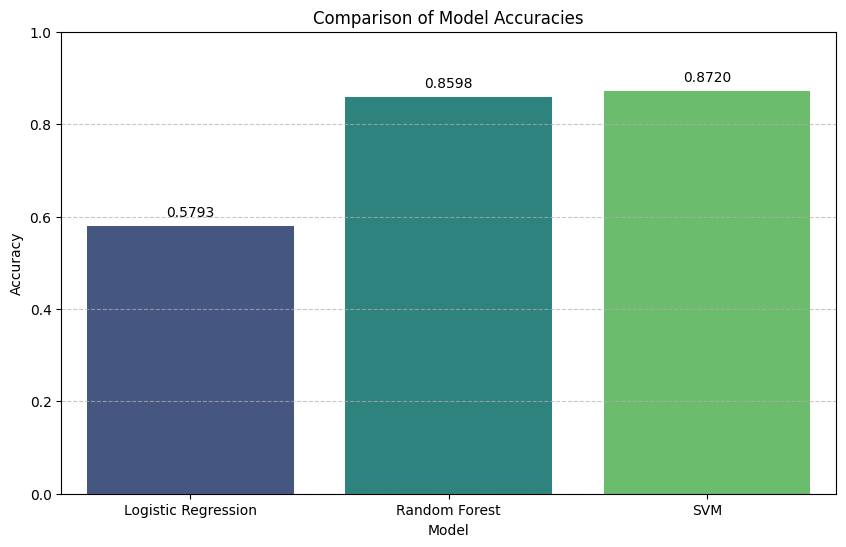

In [ ]:
model_names = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies = [
    accuracy_best,  # From Logistic Regression
    accuracy_rf,    # From Random Forest
    accuracy_svm    # From SVM
]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies, hue=model_names, palette='viridis', legend=False)
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of the bars
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()